[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QuantLet/EMQA/blob/main/EMQA_ml_forecast/EMQA_ml_forecast.ipynb)

# EMQA_ml_forecast

Complete ML forecasting pipeline for electricity price prediction.
Demonstrates train/validation/test split, model training, hyperparameter selection, and out-of-sample evaluation.

**Pipeline Steps:**
1. Data preparation and feature engineering
2. Time-aware train/validation/test split
3. Model training (Random Forest, Gradient Boosting, XGBoost)
4. Model evaluation and comparison
5. Out-of-sample forecasting

**Output:** `ml_forecast.pdf`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Professional plot styling
plt.rcParams.update({
    'figure.facecolor': 'none',
    'axes.facecolor': 'none',
    'savefig.facecolor': 'none',
    'savefig.transparent': True,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'figure.figsize': (12, 6),
})

COLORS = {
    'blue': '#1A3A6E', 'red': '#CD0000', 'green': '#2E7D32',
    'orange': '#E67E22', 'purple': '#8E44AD', 'gray': '#808080',
    'cyan': '#00BCD4', 'amber': '#B5853F'
}

def save_fig(fig, name):
    fig.savefig(name, bbox_inches='tight', transparent=True, dpi=300)
    print(f"Saved: {name}")
    if name.endswith('.pdf'):
        png_name = name[:-4] + '.png'
        fig.savefig(png_name, bbox_inches='tight', transparent=True, dpi=300)
        print(f"Saved: {png_name}")

## Step 1: Data Loading and Feature Engineering

In [2]:
# Load electricity price data
url = 'https://raw.githubusercontent.com/QuantLet/EMQA/main/EMQA_actual_vs_predicted/ro_de_prices_full.csv'
df = pd.read_csv(url, parse_dates=['date'], index_col='date')
print(f'Loaded {len(df)} observations')
print(f'Date range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Loaded 2222 observations
Date range: 2019-12-31 to 2026-01-29


,de_price,ro_price,de_temp_mean,de_temp_max,de_temp_min,ro_temp_mean,ro_temp_max,ro_temp_min,ro_nuclear,ro_hydro,ro_coal,ro_gas,ro_wind,ro_solar,gas_price,ro_consumption,ro_residual_load
date,,,,,,,,,,,,,,,,,
2019-12-31,41.880000,34.771502,5.1,7.2,2.2,-0.6,4.0,-4.4,1417.666667,151.916667,115.583333,1050.875000,1488.291667,71.833333,12.075,6838.791667,5278.666667
2020-01-01,34.694167,29.322628,0.9,4.0,-2.2,1.1,7.2,-4.0,1425.416667,197.000000,117.958333,1064.875000,1949.375000,87.625000,12.075,5808.916667,3771.916667
2020-01-02,38.288750,44.589611,-0.5,5.2,-3.8,-1.1,4.4,-4.2,1424.958333,772.416667,116.000000,1494.666667,538.750000,94.916667,12.075,6153.500000,5519.833333
2020-01-03,26.170833,51.203556,4.3,6.3,-0.6,0.2,7.3,-3.3,1406.958333,347.833333,115.458333,1560.000000,1084.958333,84.333333,12.985,6690.750000,5521.458333
2020-01-04,20.747917,40.755130,3.8,5.2,1.4,-0.1,7.1,-4.3,1425.125000,531.000000,115.291667,1729.625000,189.875000,75.833333,12.750,6770.750000,6505.041667


In [3]:
# Feature engineering (same as EMQA_ml_features)
data = df[['ro_price']].copy()

# Target: next-day price (1-step-ahead forecast)
data['target'] = data['ro_price'].shift(-1)

# Lag features
for lag in [1, 2, 3, 5, 7, 14, 30]:
    data[f'ro_lag_{lag}'] = data['ro_price'].shift(lag)

# Rolling statistics (shifted to avoid look-ahead bias)
for w in [7, 14, 30]:
    data[f'ro_ma_{w}'] = data['ro_price'].shift(1).rolling(w).mean()
    data[f'ro_std_{w}'] = data['ro_price'].shift(1).rolling(w).std()

# Temporal features
data['day_of_week'] = data.index.dayofweek
data['month'] = data.index.month
data['is_weekend'] = (data.index.dayofweek >= 5).astype(int)

# Add German price features if available
if 'de_price' in df.columns:
    data['de_lag_1'] = df['de_price'].shift(1)
    data['de_lag_7'] = df['de_price'].shift(7)
    data['spread_lag_1'] = (df['ro_price'] - df['de_price']).shift(1)

# Drop rows with NaN
data = data.dropna()

# Define feature columns
feature_cols = [c for c in data.columns if c not in ['target', 'ro_price']]
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Dataset size: {len(data)} observations")

Features (19): ['ro_lag_1', 'ro_lag_2', 'ro_lag_3', 'ro_lag_5', 'ro_lag_7', 'ro_lag_14', 'ro_lag_30', 'ro_ma_7', 'ro_std_7', 'ro_ma_14', 'ro_std_14', 'ro_ma_30', 'ro_std_30', 'day_of_week', 'month', 'is_weekend', 'de_lag_1', 'de_lag_7', 'spread_lag_1']
Dataset size: 2191 observations


## Step 2: Time-Aware Train/Validation/Test Split

For time series, we must respect temporal order. No shuffling allowed!
- **Train (60%)**: Used to fit the model
- **Validation (20%)**: Used for hyperparameter tuning
- **Test (20%)**: Final out-of-sample evaluation

In [4]:
# Time-aware split (no shuffling!)
n = len(data)
train_end = int(n * 0.6)
val_end = int(n * 0.8)

train_data = data.iloc[:train_end]
val_data = data.iloc[train_end:val_end]
test_data = data.iloc[val_end:]

# Split features and target
X_train, y_train = train_data[feature_cols], train_data['target']
X_val, y_val = val_data[feature_cols], val_data['target']
X_test, y_test = test_data[feature_cols], test_data['target']

print(f"Training:   {len(train_data):>5} obs ({train_data.index.min().date()} to {train_data.index.max().date()})")
print(f"Validation: {len(val_data):>5} obs ({val_data.index.min().date()} to {val_data.index.max().date()})")
print(f"Test:       {len(test_data):>5} obs ({test_data.index.min().date()} to {test_data.index.max().date()})")

Training:    1314 obs (2020-01-30 to 2023-09-04)
Validation:   438 obs (2023-09-05 to 2024-11-15)
Test:         439 obs (2024-11-16 to 2026-01-28)


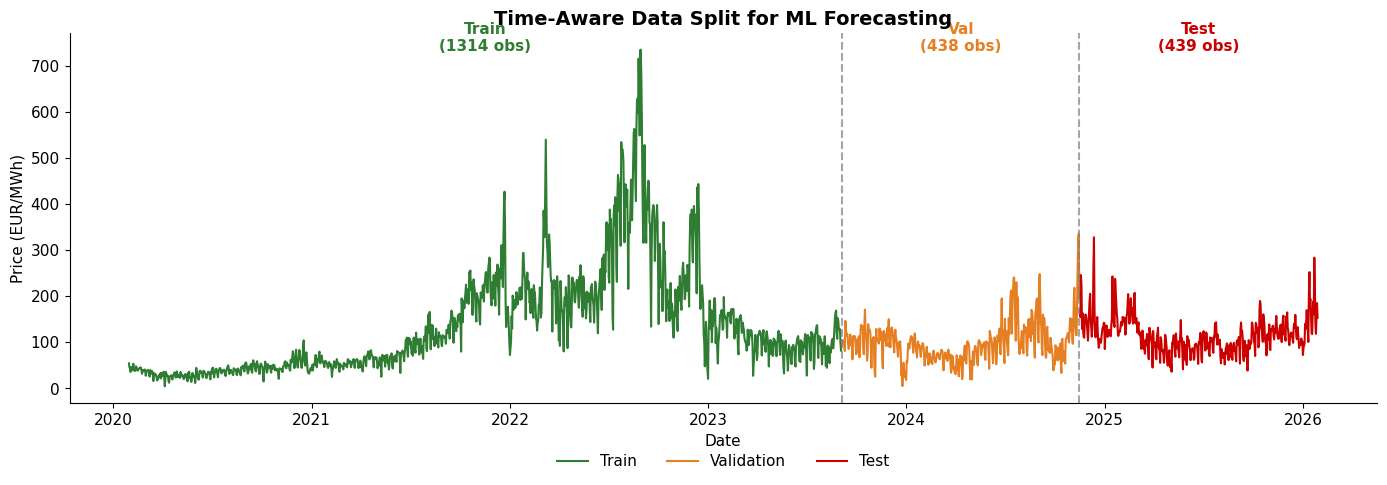

In [5]:
# Visualize the data split
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 5))

# Plot price series with colored segments
ax.plot(train_data.index, train_data['ro_price'], color=COLORS['green'], lw=1.5, label='Train')
ax.plot(val_data.index, val_data['ro_price'], color=COLORS['orange'], lw=1.5, label='Validation')
ax.plot(test_data.index, test_data['ro_price'], color=COLORS['red'], lw=1.5, label='Test')

# Add vertical lines at split points
ax.axvline(train_data.index[-1], color=COLORS['gray'], ls='--', lw=1.5, alpha=0.7)
ax.axvline(val_data.index[-1], color=COLORS['gray'], ls='--', lw=1.5, alpha=0.7)

# Annotations
ax.text(train_data.index[len(train_data)//2], ax.get_ylim()[1]*0.95, 
        f'Train\n({len(train_data)} obs)', ha='center', fontsize=11, fontweight='bold', color=COLORS['green'])
ax.text(val_data.index[len(val_data)//2], ax.get_ylim()[1]*0.95,
        f'Val\n({len(val_data)} obs)', ha='center', fontsize=11, fontweight='bold', color=COLORS['orange'])
ax.text(test_data.index[len(test_data)//2], ax.get_ylim()[1]*0.95,
        f'Test\n({len(test_data)} obs)', ha='center', fontsize=11, fontweight='bold', color=COLORS['red'])

ax.set_xlabel('Date')
ax.set_ylabel('Price (EUR/MWh)')
ax.set_title('Time-Aware Data Split for ML Forecasting', fontsize=14, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

plt.tight_layout()
plt.show()

## Step 3: Model Training

We train three popular ML models:
1. **Random Forest**: Ensemble of decision trees, robust to overfitting
2. **Gradient Boosting**: Sequential boosting, often best accuracy
3. **XGBoost**: Optimized gradient boosting implementation

In [6]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Try to import XGBoost (optional)
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed - skipping XGB model")

def evaluate_model(y_true, y_pred, name):
    """Calculate and print model metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Direction accuracy
    actual_dir = np.sign(np.diff(np.concatenate([[y_true.iloc[0]], y_true.values])))
    pred_dir = np.sign(np.diff(np.concatenate([[y_true.iloc[0]], y_pred])))
    dir_acc = np.mean(actual_dir == pred_dir) * 100
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'Dir_Acc': dir_acc}

XGBoost not installed - skipping XGB model


In [7]:
# Define models with reasonable hyperparameters
models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=200, 
        max_depth=10, 
        min_samples_split=5,
        random_state=42, 
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, 
        max_depth=5, 
        learning_rate=0.1,
        random_state=42
    ),
}

if HAS_XGB:
    models['XGBoost'] = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )

# Train models and evaluate on validation set
val_results = []
trained_models = {}

print("Training models...\n")
print("="*70)
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'R2':>10} {'Dir.Acc':>10}")
print("="*70)

for name, model in models.items():
    # Train on training data
    model.fit(X_train, y_train)
    trained_models[name] = model
    
    # Predict on validation set
    val_pred = model.predict(X_val)
    
    # Evaluate
    result = evaluate_model(y_val, val_pred, name)
    val_results.append(result)
    
    print(f"{name:<20} {result['MAE']:>10.2f} {result['RMSE']:>10.2f} {result['R2']:>10.3f} {result['Dir_Acc']:>9.1f}%")

print("="*70)

Training models...

Model                       MAE       RMSE         R2    Dir.Acc
Random Forest             20.76      29.60      0.528      63.5%


Gradient Boosting         20.43      29.09      0.544      67.1%


In [8]:
# Select best model based on validation RMSE
val_df = pd.DataFrame(val_results)
best_model_name = val_df.loc[val_df['RMSE'].idxmin(), 'name']
best_model = trained_models[best_model_name]

print(f"\nBest model on validation set: {best_model_name}")


Best model on validation set: Gradient Boosting


## Step 4: Model Comparison Visualization

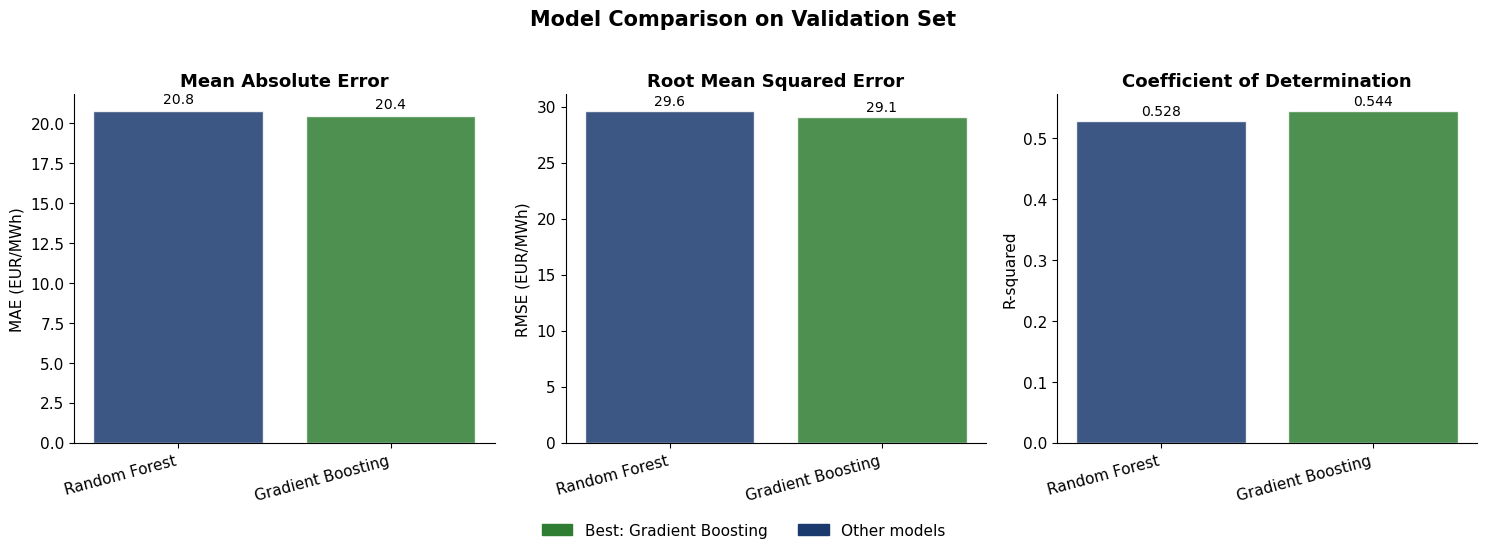

In [9]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = val_df['name'].tolist()
x = np.arange(len(model_names))

# Panel 1: MAE comparison
ax1 = axes[0]
colors = [COLORS['green'] if n == best_model_name else COLORS['blue'] for n in model_names]
bars = ax1.bar(x, val_df['MAE'], color=colors, alpha=0.85, edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=15, ha='right')
ax1.set_ylabel('MAE (EUR/MWh)')
ax1.set_title('Mean Absolute Error', fontsize=13, fontweight='bold')
for bar, val in zip(bars, val_df['MAE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', fontsize=10)

# Panel 2: RMSE comparison
ax2 = axes[1]
bars = ax2.bar(x, val_df['RMSE'], color=colors, alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.set_ylabel('RMSE (EUR/MWh)')
ax2.set_title('Root Mean Squared Error', fontsize=13, fontweight='bold')
for bar, val in zip(bars, val_df['RMSE']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{val:.1f}', ha='center', fontsize=10)

# Panel 3: R2 comparison
ax3 = axes[2]
bars = ax3.bar(x, val_df['R2'], color=colors, alpha=0.85, edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(model_names, rotation=15, ha='right')
ax3.set_ylabel('R-squared')
ax3.set_title('Coefficient of Determination', fontsize=13, fontweight='bold')
for bar, val in zip(bars, val_df['R2']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{val:.3f}', ha='center', fontsize=10)

# Add legend
import matplotlib.patches as mpatches
legend_items = [
    mpatches.Patch(color=COLORS['green'], label=f'Best: {best_model_name}'),
    mpatches.Patch(color=COLORS['blue'], label='Other models')
]
fig.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, 0.02),
           frameon=False, ncol=2)

fig.suptitle('Model Comparison on Validation Set', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()

## Step 5: Final Test Set Evaluation

Evaluate the best model on the held-out test set (truly out-of-sample).

In [10]:
# Retrain best model on train + validation data
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Clone and retrain best model
if best_model_name == 'Random Forest':
    final_model = RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1
    )
elif best_model_name == 'Gradient Boosting':
    final_model = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    )
else:  # XGBoost
    final_model = XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1
    )

final_model.fit(X_train_full, y_train_full)

# Predict on test set
test_pred = final_model.predict(X_test)

# Evaluate
test_result = evaluate_model(y_test, test_pred, best_model_name)

# Naive benchmark (tomorrow = today)
naive_pred = test_data['ro_price'].shift(1).dropna().values
y_test_aligned = y_test.iloc[1:].values
test_pred_aligned = test_pred[1:]

mse_model = mean_squared_error(y_test_aligned, test_pred_aligned)
mse_naive = mean_squared_error(y_test_aligned, naive_pred)
r2_oos = 1 - mse_model / mse_naive

print("\n" + "="*60)
print(f"   FINAL TEST SET RESULTS: {best_model_name}")
print("="*60)
print(f"{'MAE':<25} {test_result['MAE']:.2f} EUR/MWh")
print(f"{'RMSE':<25} {test_result['RMSE']:.2f} EUR/MWh")
print(f"{'R-squared':<25} {test_result['R2']:.3f}")
print(f"{'Direction Accuracy':<25} {test_result['Dir_Acc']:.1f}%")
print(f"{'R2_OOS (vs naive)':<25} {r2_oos*100:.1f}%")
print("="*60)
if r2_oos > 0:
    print(f">>> Model beats naive benchmark by {r2_oos*100:.1f}%")
else:
    print(">>> Model does NOT beat naive benchmark")


   FINAL TEST SET RESULTS: Gradient Boosting
MAE                       19.65 EUR/MWh
RMSE                      28.08 EUR/MWh
R-squared                 0.460
Direction Accuracy        63.8%
R2_OOS (vs naive)         45.3%
>>> Model beats naive benchmark by 45.3%


In [11]:
# Get bootstrap confidence intervals from RF trees (if applicable)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

if isinstance(final_model, RandomForestRegressor) and hasattr(final_model, 'estimators_'):
    # Random Forest: use individual tree predictions
    tree_preds = np.array([tree.predict(X_test) for tree in final_model.estimators_])
    ci_lo = np.percentile(tree_preds, 2.5, axis=0)
    ci_hi = np.percentile(tree_preds, 97.5, axis=0)
    has_ci = True
elif isinstance(final_model, GradientBoostingRegressor) and hasattr(final_model, 'staged_predict'):
    # Gradient Boosting: use staged predictions
    staged = np.array(list(final_model.staged_predict(X_test)))
    half = max(1, final_model.n_estimators // 2)
    ci_lo = np.percentile(staged[half:], 2.5, axis=0)
    ci_hi = np.percentile(staged[half:], 97.5, axis=0)
    has_ci = True
else:
    has_ci = False

Saved: ml_forecast.pdf


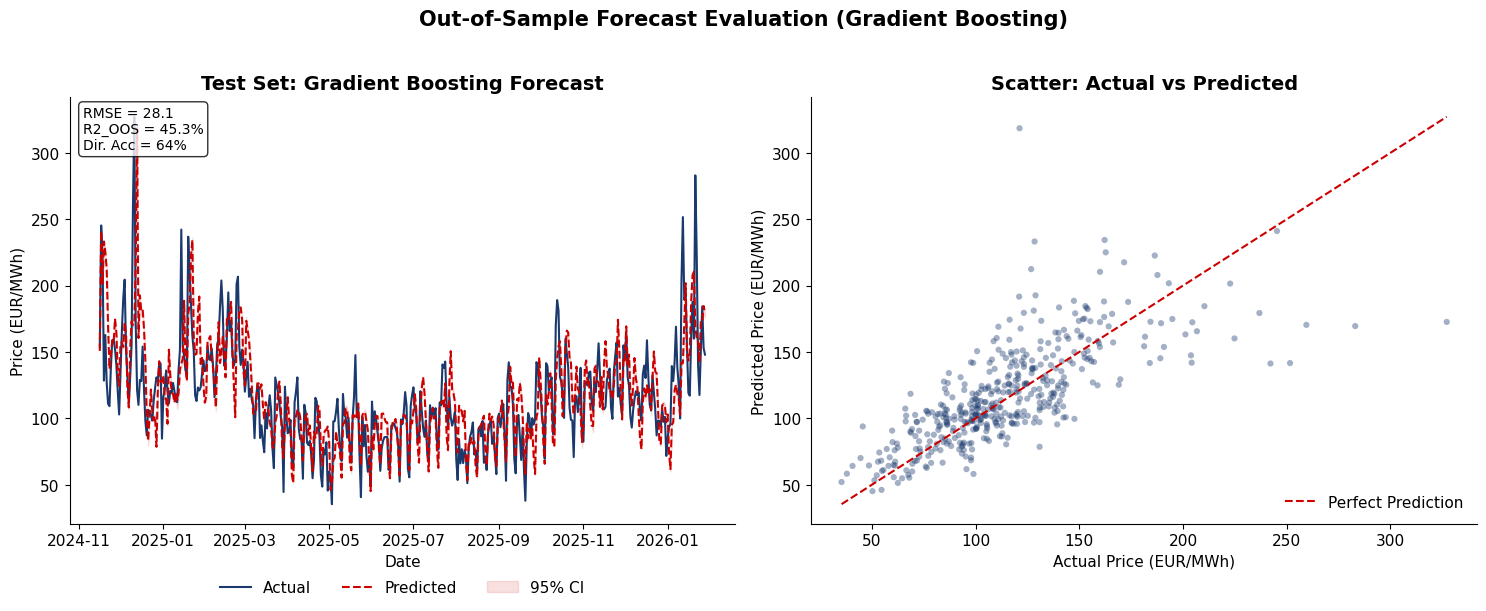

In [12]:
# Plot: Actual vs Predicted on Test Set
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Time series comparison
ax1 = axes[0]
ax1.plot(test_data.index, y_test.values, color=COLORS['blue'], lw=1.5, label='Actual')
ax1.plot(test_data.index, test_pred, color=COLORS['red'], lw=1.5, ls='--', label='Predicted')

if has_ci:
    ax1.fill_between(test_data.index, ci_lo, ci_hi, color=COLORS['red'], alpha=0.12, label='95% CI')

# Add metrics annotation
textstr = f'RMSE = {test_result["RMSE"]:.1f}\nR2_OOS = {r2_oos*100:.1f}%\nDir. Acc = {test_result["Dir_Acc"]:.0f}%'
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax1.set_xlabel('Date')
ax1.set_ylabel('Price (EUR/MWh)')
ax1.set_title(f'Test Set: {best_model_name} Forecast', fontsize=14, fontweight='bold')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), frameon=False, ncol=3)

# Panel 2: Scatter plot
ax2 = axes[1]
ax2.scatter(y_test.values, test_pred, color=COLORS['blue'], alpha=0.4, s=20, edgecolors='none')

# Perfect prediction line
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
ax2.plot(lims, lims, color=COLORS['red'], ls='--', lw=1.5, label='Perfect Prediction')

ax2.set_xlabel('Actual Price (EUR/MWh)')
ax2.set_ylabel('Predicted Price (EUR/MWh)')
ax2.set_title('Scatter: Actual vs Predicted', fontsize=14, fontweight='bold')
ax2.legend(loc='lower right', frameon=False)

fig.suptitle(f'Out-of-Sample Forecast Evaluation ({best_model_name})', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
save_fig(fig, 'ml_forecast.pdf')
plt.show()

## Step 6: Feature Importance Analysis

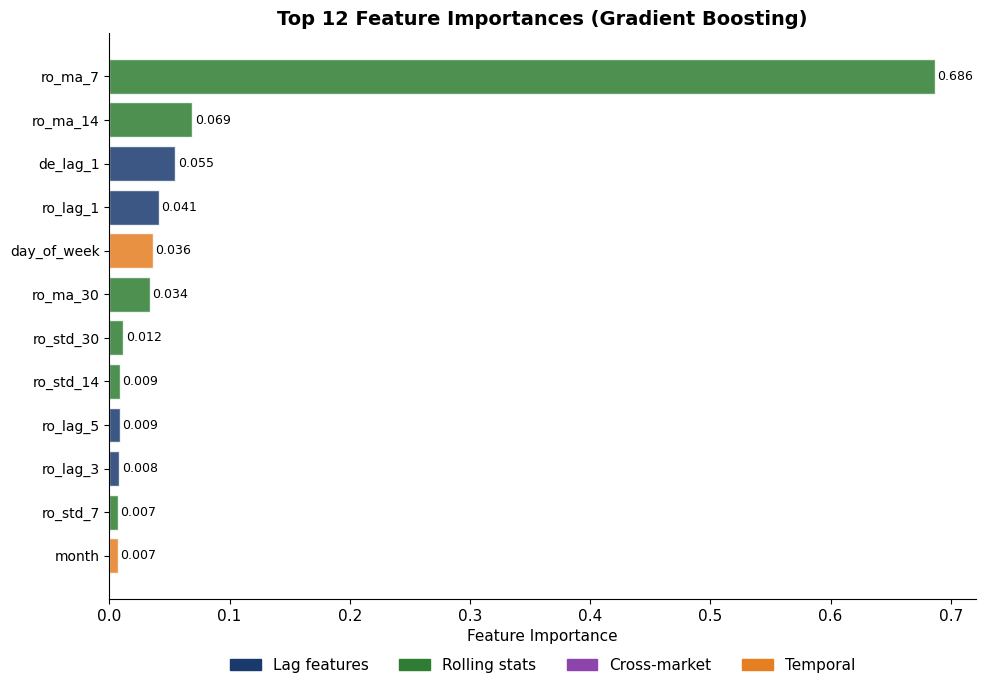

In [13]:
# Extract feature importances
if hasattr(final_model, 'feature_importances_'):
    importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    top_features = importance.tail(12)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Color by feature type
    def get_color(name):
        if 'lag' in name:
            return COLORS['blue']
        elif 'ma_' in name or 'std_' in name:
            return COLORS['green']
        elif 'de_' in name or 'spread' in name:
            return COLORS['purple']
        else:
            return COLORS['orange']
    
    colors = [get_color(f) for f in top_features.index]
    bars = ax.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.85, edgecolor='white')
    
    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features.index, fontsize=10)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 12 Feature Importances ({best_model_name})', fontsize=14, fontweight='bold')
    
    for i, val in enumerate(top_features.values):
        ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)
    
    # Legend
    import matplotlib.patches as mpatches
    legend_items = [
        mpatches.Patch(color=COLORS['blue'], label='Lag features'),
        mpatches.Patch(color=COLORS['green'], label='Rolling stats'),
        mpatches.Patch(color=COLORS['purple'], label='Cross-market'),
        mpatches.Patch(color=COLORS['orange'], label='Temporal'),
    ]
    ax.legend(handles=legend_items, loc='upper center', bbox_to_anchor=(0.5, -0.08),
              frameon=False, ncol=4)
    
    plt.tight_layout()
    plt.show()

In [14]:
# Summary
print("\n" + "="*70)
print("   ML FORECASTING PIPELINE SUMMARY")
print("="*70)
print(f"\nData: Romanian electricity prices")
print(f"Features: {len(feature_cols)} engineered features")
print(f"Target: Next-day price (1-step-ahead forecast)")
print(f"\nBest Model: {best_model_name}")
print(f"\nTest Set Performance:")
print(f"  - MAE:  {test_result['MAE']:.2f} EUR/MWh")
print(f"  - RMSE: {test_result['RMSE']:.2f} EUR/MWh")
print(f"  - R2:   {test_result['R2']:.3f}")
print(f"  - R2_OOS (vs naive): {r2_oos*100:.1f}%")
print(f"  - Direction Accuracy: {test_result['Dir_Acc']:.1f}%")
print("="*70)


   ML FORECASTING PIPELINE SUMMARY

Data: Romanian electricity prices
Features: 19 engineered features
Target: Next-day price (1-step-ahead forecast)

Best Model: Gradient Boosting

Test Set Performance:
  - MAE:  19.65 EUR/MWh
  - RMSE: 28.08 EUR/MWh
  - R2:   0.460
  - R2_OOS (vs naive): 45.3%
  - Direction Accuracy: 63.8%
